# Tasca S11.01. Visualització de Dades amb Python i Power BI📊

# Descripció
Aquesta pràctica integra l'ús de Python amb les llibreries Pandas, Matplotlib, Seaborn o Plotly, així com la seva integració amb Power BI. Treballaràs tot el procés des de la connexió a MySQL, la creació de visualitzacions avançades en Python i finalment la incorporació d'aquestes visualitzacions a un informe dinàmic a Power BI.

## Nivell 1

Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

### 1. Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

In [1]:
# Para que Pandas pueda leer los datos directamente desde MySQL, utilizo la librería SQLAlchemy junto con el conector PyMySQL.
# !pip install pymysql sqlalchemy pandas

# Importo las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, inspect 
import getpass # Librería para ocultar contraseñas
import os # Libreria que permite interactuar con funciones del sistema

In [2]:
# Defino mis credenciales
usuario = "root"          
host = "localhost"        
puerto = "3306"           
baseDatos = "transactionsSPRINT4" 

# Solicito la contraseña de forma segura
contrasena = getpass.getpass("Introduce tu contraseña de MySQL: ")

# Creo la conexión
cadenaConexion = f"mysql+pymysql://{usuario}:{contrasena}@{host}:{puerto}/{baseDatos}"
motor = create_engine(cadenaConexion)

# En lugar de escribir yo una lista con los nombres de las tablas, uso el inspector de SQLAlchemy
# para que me diga qué tablas existen realmente en mi base de datos
inspector = inspect(motor)
listaTablas = inspector.get_table_names()

# Creo mi diccionario de DataFrames
misDatos = {}

# Ahora recorro la lista que el propio sistema ha generado
for tabla in listaTablas:
    # Escribo la consulta SQL automática
    consultaSql = f"SELECT * FROM {tabla};"
    
    # Cargo los datos y los guardo dinámicamente
    misDatos[tabla] = pd.read_sql(consultaSql, con=motor)
    
    print(f"Tabla '{tabla}' cargada dinámicamente con {len(misDatos[tabla])} filas.")

# Confirmo que todo está ahí revisando las claves de mi diccionario
print("\nTablas cargadas en 'misDatos':", misDatos.keys())

Tabla 'company' cargada dinámicamente con 100 filas.
Tabla 'credit_card' cargada dinámicamente con 5000 filas.
Tabla 'estado_tarjeta' cargada dinámicamente con 5000 filas.
Tabla 'ProductosPorTransaccion' cargada dinámicamente con 253391 filas.
Tabla 'products' cargada dinámicamente con 100 filas.
Tabla 'transaction' cargada dinámicamente con 100000 filas.
Tabla 'user' cargada dinámicamente con 5000 filas.

Tablas cargadas en 'misDatos': dict_keys(['company', 'credit_card', 'estado_tarjeta', 'ProductosPorTransaccion', 'products', 'transaction', 'user'])


### 2. Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.
Recorda: quan seleccionis les columnes, pensa sempre en el mètode que faràs servir i inclou les que calguin per a la funció de visualització que vulguis utilitzar.

#### Una variable numèrica.

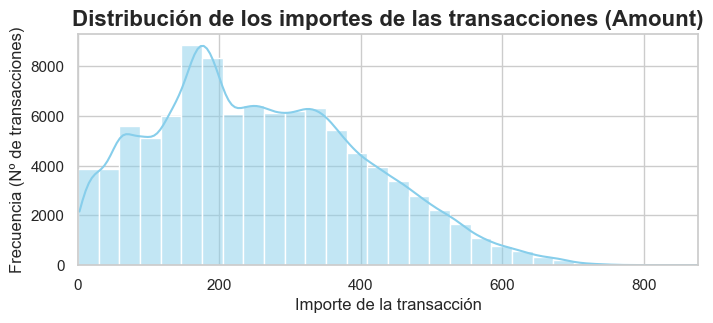

In [3]:
# Selecciono el DataFrame de transacciones de mi diccionario
dfTransaction = misDatos["transaction"]

# Configuro el estilo general de los gráficos para darle un toque profesional
sns.set_theme(style="whitegrid")

# Creo un lienzo con un tamaño adecuado
plt.figure(figsize=(8, 3))

# Dibujo un histograma para la variable numérica "amount"
# Añado "kde=True" para que también dibuje la línea de tendencia (curva de densidad)
# He añadido "binrange" para que mis barras comiencen exactamente en el valor 0
sns.histplot(data=dfTransaction, x="amount", bins=30, kde=True, color="skyblue", 
             binrange=(0, dfTransaction['amount'].max()))

# He ajustado el límite del eje X para eliminar el espacio en blanco y que empiece en 0
plt.xlim(0, dfTransaction['amount'].max())

# Fuerzo las etiquetas del eje X para que sigan una escala de 200 en 200
plt.xticks([0, 200, 400, 600, 800])

# Añado los títulos y las etiquetas de los ejes para que el gráfico sea autoexplicativo
plt.title("Distribución de los importes de las transacciones (Amount)", fontsize=16, fontweight="bold")
plt.xlabel("Importe de la transacción", fontsize=12)
plt.ylabel("Frecuencia (Nº de transacciones)", fontsize=12)

# Muestro el resultado por pantalla
plt.show()

**Interpretación:** La gran mayoría de transacciones se concentra entre los 50 y 400, con un pico destacado alrededor de los 150-200. A partir de los 400, la frecuencia disminuye progresivamente hasta desaparecer cerca de los 800.

#### Dues variables numèriques.

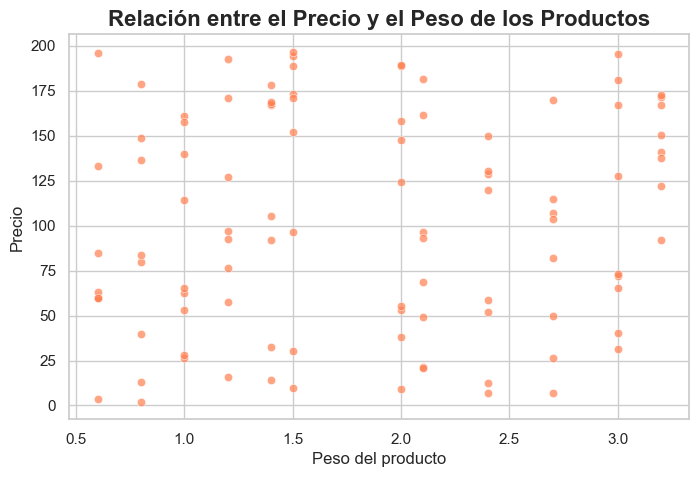

In [4]:
# Selecciono el DataFrame de productos
dfProducts = misDatos["products"]

# Creo el lienzo
plt.figure(figsize=(8, 5))

# Dibujo un gráfico de dispersión (scatterplot)
# Supongamos que queremos ver si los productos más pesados son más caros
sns.scatterplot(data=dfProducts, x="weight", y="price", color="coral", alpha=0.7)

# Títulos y etiquetas
plt.title("Relación entre el Precio y el Peso de los Productos", fontsize=16, fontweight="bold")
plt.xlabel("Peso del producto", fontsize=12)
plt.ylabel("Precio", fontsize=12)

# Muestro el gráfico
plt.show()

#### Una variable categòrica.

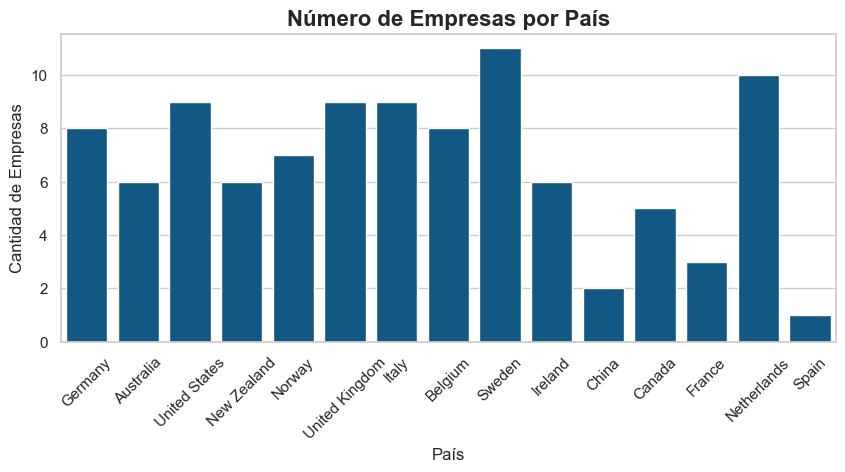

In [5]:
# Selecciono el DataFrame de compañías
dfCompany = misDatos["company"]

# Creo el lienzo
plt.figure(figsize=(10, 4))

# Dibujo un gráfico de barras contando las ocurrencias de cada país
sns.countplot(data=dfCompany, x="country", color="#005b96")

# Roto las etiquetas del eje X por si hay muchos países y se solapan
plt.xticks(rotation=45)

# Títulos y etiquetas con formato profesional
plt.title("Número de Empresas por País", fontsize=16, fontweight="bold")
plt.xlabel("País", fontsize=12)
plt.ylabel("Cantidad de Empresas", fontsize=12)

# Muestro el gráfico
plt.show()

**Interpretación:** Suecia y los Países Bajos lideran la lista con 11 y 10 empresas respectivamente, seguidos de cerca por los EE. UU., el Reino Unido e Italia. España registra la menor representación con solo una empresa.

#### Una variable categòrica i una numèrica.

/var/folders/7n/r9wpqsvn3fjdmkznp35dflqh0000gn/T/ipykernel_3945/97094351.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfTransaction, x="declined", y="amount", palette="Set2")


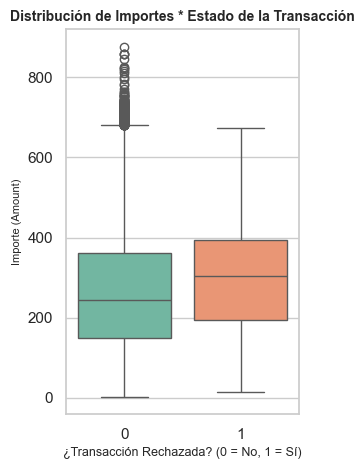

In [6]:
# Vuelvo a usar el DataFrame de transacciones
dfTransaction = misDatos["transaction"]

# Creo el lienzo
plt.figure(figsize=(3, 5))

# Dibujo un boxplot. "declined" es categórica (ej. 0 o 1) y "amount" es numèrica
sns.boxplot(data=dfTransaction, x="declined", y="amount", palette="Set2")

# Títulos y etiquetas
plt.title("Distribución de Importes * Estado de la Transacción", fontsize=10, fontweight="bold")
plt.xlabel("¿Transacción Rechazada? (0 = No, 1 = Sí)", fontsize=9)
plt.ylabel("Importe (Amount)", fontsize=8)

plt.show()

**Interpretación:** La mediana de los importes es ligeramente mayor en las transacciones rechazadas (1). Curiosamente, los valores extremos más altos (outliers cercanos a 900) solo se observan en las compras que sí fueron aceptadas (0).

#### Dues variables categòriques.

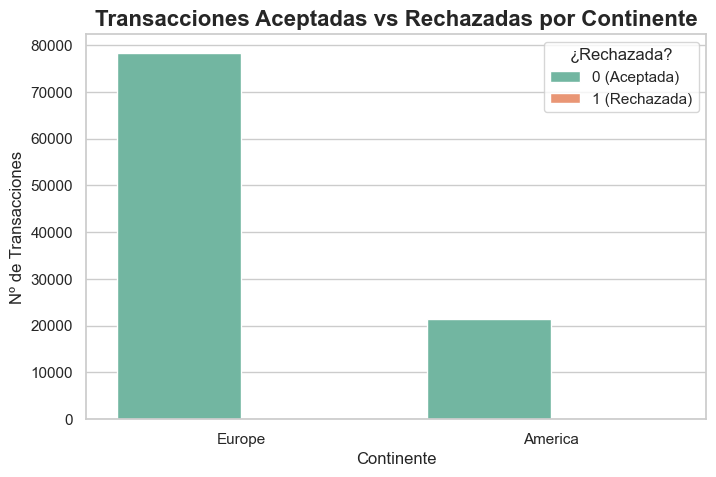

In [7]:
# Uno la tabla de transacciones con la de usuarios
# Le indico que use "user_id" de la tabla izquierda (transaction) y "id" de la derecha (user)
dfTransactionUser = pd.merge(misDatos["transaction"], misDatos["user"], left_on="user_id", right_on="id")

# Creo el lienzo
plt.figure(figsize=(8, 5))

# Dues variables categòriques: X = 'continent', Color (hue) = 'declined'
sns.countplot(data=dfTransactionUser, x="continent", hue="declined", palette="Set2")

# Títulos y etiquetas
plt.title("Transacciones Aceptadas vs Rechazadas por Continente", fontsize=16, fontweight="bold")
plt.xlabel("Continente", fontsize=12)
plt.ylabel("Nº de Transacciones", fontsize=12)

# Personalizo la leyenda para que se entienda mejor (asumiendo 0=No, 1=Sí)
plt.legend(title="¿Rechazada?", labels=["0 (Aceptada)", "1 (Rechazada)"])

# Muestro el resultado
plt.show()

**Interpretación:** El volumen de transacciones en Europa cuadruplica al de América, siendo la gran mayoría aceptadas en ambos continentes. La tasa de rechazo es tan baja que las transacciones denegadas apenas son visibles a esta escala, lo que sugiere un sistema muy saludable.

#### Tres variables combinades.

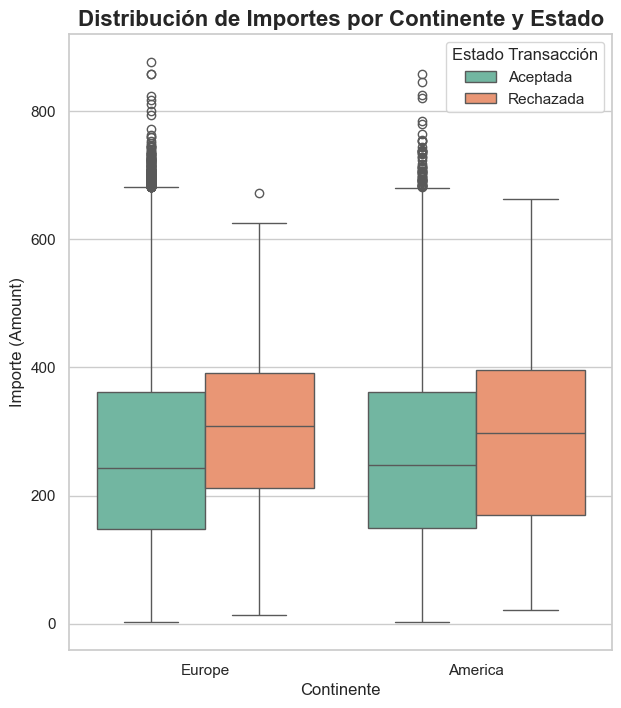

In [8]:
# Creo una columna temporal con etiquetas claras para que la leyenda salga bien sola
dfTransactionUser["estado_nombre"] = dfTransactionUser["declined"].map({0: "Aceptada", 1: "Rechazada"})

# Creo el lienzo
plt.figure(figsize=(7, 8))

# Dibujo el boxplot usando la nueva columna para el "hue"
sns.boxplot(data=dfTransactionUser, x="continent", y="amount", hue="estado_nombre", palette="Set2")

# Títulos y etiquetas
plt.title("Distribución de Importes por Continente y Estado", fontsize=16, fontweight="bold")
plt.xlabel("Continente", fontsize=12)
plt.ylabel("Importe (Amount)", fontsize=12)

# Ahora no hace falta que le pase los labels manualmente, solo el título de la leyenda
plt.legend(title="Estado Transacción")

plt.show()

**Interpretación:** El comportamiento es consistente en ambos continentes: las transacciones rechazadas presentan una mediana de importe superior a las aceptadas. Curiosamente, los valores atípicos más extremos (compras cercanas a 900) solo aparecen en las transacciones aprobadas, tanto en Europa como en América.

#### Crea un Pairplot.

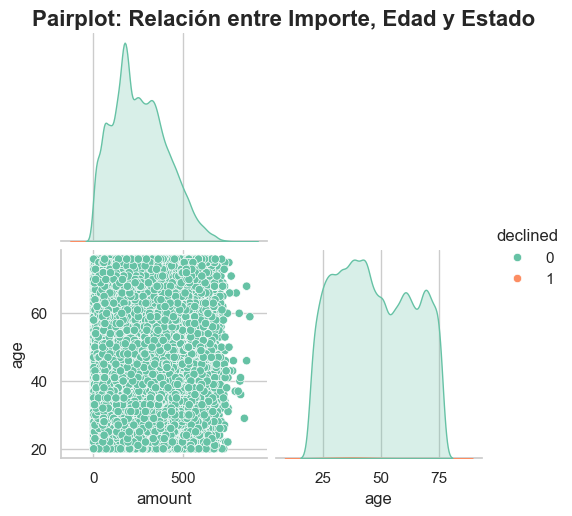

In [9]:
# Calculo la edad del usuario para tener una variable numérica extra
dfTransactionUser["birth_date"] = pd.to_datetime(dfTransactionUser["birth_date"])
dfTransactionUser["age"] = pd.Timestamp.now().year - dfTransactionUser["birth_date"].dt.year

# Selecciono solo las columnas clave para que el Pairplot no intente graficar IDs o latitudes
columnasPairplot = ["amount", "age", "declined"]
dfTransactionUserPairplot = dfTransactionUser[columnasPairplot]

# Creo el pairplot, usando 'declined' para colorear
# "corner=True" quita los gráficos duplicados de la parte superior derecha para que quede más limpio
sns.pairplot(dfTransactionUserPairplot, hue="declined", palette="Set2", corner=True)

# Añado un título general
plt.suptitle("Pairplot: Relación entre Importe, Edad y Estado", y=1.02, fontsize=16, fontweight="bold")

plt.show()

**Interpretación:** El Pairplot confirma una distribución demográfica muy equilibrada (usuarios entre 20 y 80 años) y la ausencia de correlación entre la edad y el importe gastado. Predomina de manera casi absoluta el verde, eso valida visualmente que la tasa de rechazo es dimninuta en todos los perfiles de usuario.

## Nivell 2

### 1. Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.

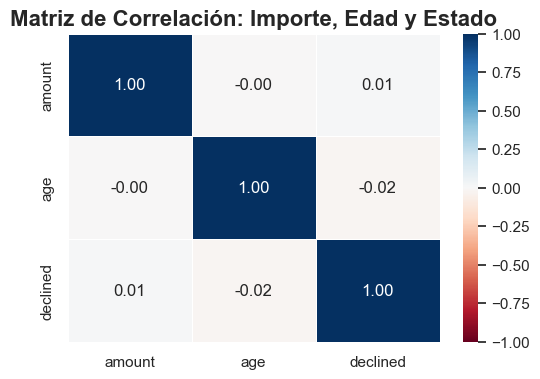

In [10]:
# Calculo la matriz de correlación
corrMatrixTransactionUser = dfTransactionUser[['amount', 'age', 'declined']].corr()

# Configuro el lienzo
plt.figure(figsize=(6, 4))

# Dibujo el mapa de calor (Heatmap)
# Añado vmin=-1 y vmax=1 para fijar los límites de la escala
sns.heatmap(corrMatrixTransactionUser, 
            annot=True, 
            cmap='RdBu', 
            center=0, 
            vmin=-1, 
            vmax=1, 
            fmt=".2f", 
            linewidths=0.5)

plt.title("Matriz de Correlación: Importe, Edad y Estado", fontsize=16, fontweight="bold")
plt.show()

**Interpretación:** La matriz muestra una ausencia total de correlación lineal (valores próximos a 0) entre las variables. Esto confirma que ni la edad ni el importe son factores determinantes para predecir si una transacción será rechazada.

### 2. Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades.

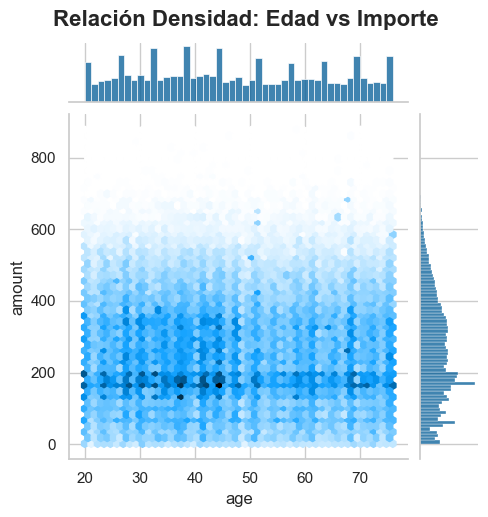

In [11]:
# Implemento un Jointplot
# kind="hex" agrupa los puntos en hexágonos para ver mejor la densidad sin saturar
# "height" controla el tamaño del cuadrado (en pulgadas)
grid = sns.jointplot(data=dfTransactionUser, x="age", y="amount", kind="hex", color="#005b96", height=5)

# Ajusto el título (en jointplot es un poco diferente)
grid.fig.suptitle("Relación Densidad: Edad vs Importe", y=1.03, fontsize=16, fontweight="bold")

plt.show()

**Interpretación:** La densidad de transacciones es uniforme a lo largo de todas las edades, con una mayor concentración en importes inferiores a 400. No observo ningún patrón de comportamiento o preferencia de gasto vinculado a la etapa de vida del usuario.

## Nivell 3

### 1. Transfereix totes les visualitzacions del Nivell 1 a Power BI utilitzant scripts de Python.
Recorda: quan carreguis els teus dataframes a Power BI, assegura't d’incloure una columna identificadora o una combinació de columnes que garanteixi la unicitat de cada registre. Per defecte, Power BI elimina duplicats i podries perdre informació.

In [12]:
# Me aseguro de que esta sea la ruta de la carpeta que ve la VM
rutaCompartida = "/Users/etornos99/CarpetaVM" 

# BUCLE DE EXPORTACIÓN
print("Iniciando exportación de tablas...")

for nombreOriginal in misDatos.keys():
    # Creo el nombre con el formato: df + Nombre
    # Usamos capitalize() para que "transaction" pase a "Transaction"
    nuevoNombre = "df" + nombreOriginal[0].upper() + nombreOriginal[1:]
    
    # Construyo la ruta completa del archivo
    rutaArchivo = os.path.join(rutaCompartida, f"{nuevoNombre}.csv")
    
    # Exporto el DataFrame a CSV
    misDatos[nombreOriginal].to_csv(rutaArchivo, index=False)
    
    print(f"{nombreOriginal} -> {nuevoNombre}.csv")

# EXPORTACIÓN DE LA UNIÓN
dfTransactionUser.to_csv(os.path.join(rutaCompartida, "dfTransactionUser.csv"), index=False)
print("Tabla especial 'dfTransactionUser.csv' generada con éxito.")


Iniciando exportación de tablas...
company -> dfCompany.csv
credit_card -> dfCredit_card.csv
estado_tarjeta -> dfEstado_tarjeta.csv
ProductosPorTransaccion -> dfProductosPorTransaccion.csv
products -> dfProducts.csv
transaction -> dfTransaction.csv
user -> dfUser.csv
Tabla especial 'dfTransactionUser.csv' generada con éxito.
